## Precipitation Partitioning
Follows Wang 2019

In [2]:
%matplotlib ipympl
import matplotlib.pyplot as plt
import numpy as np
from buildforcing.datasets import siteNLDAS
from datetime import datetime
import os

### Key Functions

In [3]:
# Saturation vapor pressure over liquid water
def esat_liq(T):
    # Magnus formula - see Huang 2018
    # T in degC, esat in Pa
    return 610.94 * np.exp((17.625 * T) / (T + 243.04))  # in Pa

In [4]:
# Saturation vapor pressure over ice
def esat_ice(T):
    # Also from Huang 2018
    # T in degC, esat in Pa
    return 611.21 * np.exp((22.587 * T) / (T + 273.86))  # in Pa

In [5]:
# Specific humidity to vapor pressure
def q_to_e(q, p):
    # q in kg/kg, p in Pa, e in Pa
    # See downloaded list of formulas from "plymouth state"
    return (q * p) / (0.622 + 0.378 * q)

In [6]:
# Psychrometric constant
def psychro_const(p):
    # p in Pa, gamma in Pa/K
    cp = 1005.7  # J/(kg·K)
    Lv = 2.5e6  # J/kg
    epsilon = 0.622  # Rd/Rv
    return (cp * p) / (epsilon * Lv)  # in Pa/K

In [7]:
# Relative humidity from q and Tair
def rh_from_q_tair(q, Tair, p):
    # q in kg/kg, Tair in degC, p in Pa, rh in fraction
    e = q_to_e(q, p)
    esat = esat_liq(Tair)
    return e / esat  # fraction

In [8]:
# Vapor pressure from wet-bulb temperature
def e_from_wetbulb(Ta, Twb, p):
    # Twb in degC, p in Pa, e in Pa
    if Twb < 0:
        esat = esat_ice(Twb)
    else:
        esat = esat_liq(Twb)
    gamma = psychro_const(p)
    return esat - gamma * (Ta - Twb)  # in Pa

### Solve for wet bulb temperature using air temperature, specific humidity, and pressure

In [9]:
def calculate_wetbulb(Ta_c, q, p_pa):
    # Ta in degC, q in kg/kg, p in Pa
    # Returns Twb in degC
    e = q_to_e(q, p_pa)  # in Pa
    gamma = psychro_const(p_pa)  # in Pa/K

    # Initial guess for Twb
    Tmax = Ta_c
    Tmin = Ta_c - 40.0  # Assume wet-bulb won't be lower than 40C below air temp
    Twb = Tmin # Just to initialize

    # Iterative solution based in e_from_wetbulb
    for _ in range(10):
        Twb = (Tmax + Tmin) / 2.0  # Midpoint estimate
        
        e_calc = e_from_wetbulb(Ta_c, Twb, p_pa)
        error = e - e_calc
        
        if abs(error) < 0.01:
            break

        # Update bounds
        if error > 0:
            # Actual vapor pressure > calculated vapor pressure
            # Wet bulb temperature is too low
            Tmin = Twb
        else:
            # Actual vapor pressure < calculated vapor pressure
            # Wet bulb temperature is too high
            Tmax = Twb

    # If final Twb is > Ta, throw an error
    if Twb > Ta_c:
        raise ValueError("Calculated wet-bulb temperature is greater than air temperature.")
    
    return Twb
        

### Test Twb using some NLDAS data

In [10]:
quemazon = siteNLDAS('Quemazon',datetime(2010,3,1),datetime(2010,4,1),storage_path=os.environ['NLDAS_PATH'])
quemazon.loadNetCDF()

In [11]:
quemazon.data.head()

,LWdown,PSurf,Qair,Rainf,SWdown,Tair,Wind_E,Wind_N,elevation
Date&Time,,,,,,,,,
2010-03-01 00:00:00+00:00,242.23,71178.7,0.003480,0.0702,108.208,270.65,2.58,-3.11,2827.595947
2010-03-01 01:00:00+00:00,242.13,71242.1,0.003265,0.4274,0.000,269.31,2.22,-3.13,2827.595947
2010-03-01 02:00:00+00:00,242.03,71305.3,0.003051,0.0000,0.000,267.97,1.85,-3.16,2827.595947
2010-03-01 03:00:00+00:00,243.70,71367.6,0.002838,0.0000,0.000,266.63,1.48,-3.18,2827.595947
2010-03-01 04:00:00+00:00,243.70,71416.1,0.002852,0.0000,0.000,266.60,1.48,-3.27,2827.595947


In [12]:
quemazon_data = quemazon.data[['Tair','Qair','PSurf']].copy()
quemazon_data['Tair_c'] = quemazon_data['Tair'] - 273.15  # Convert to degC

In [13]:
quemazon_data['RH'] = quemazon_data.apply(lambda row: rh_from_q_tair(row['Qair'], row['Tair_c'], row['PSurf']), axis=1)
quemazon_data['Twb_c'] = quemazon_data.apply(lambda row: calculate_wetbulb(row['Tair_c'], row['Qair'], row['PSurf']), axis=1)

Text(0.5, 0, 'Date & Time')

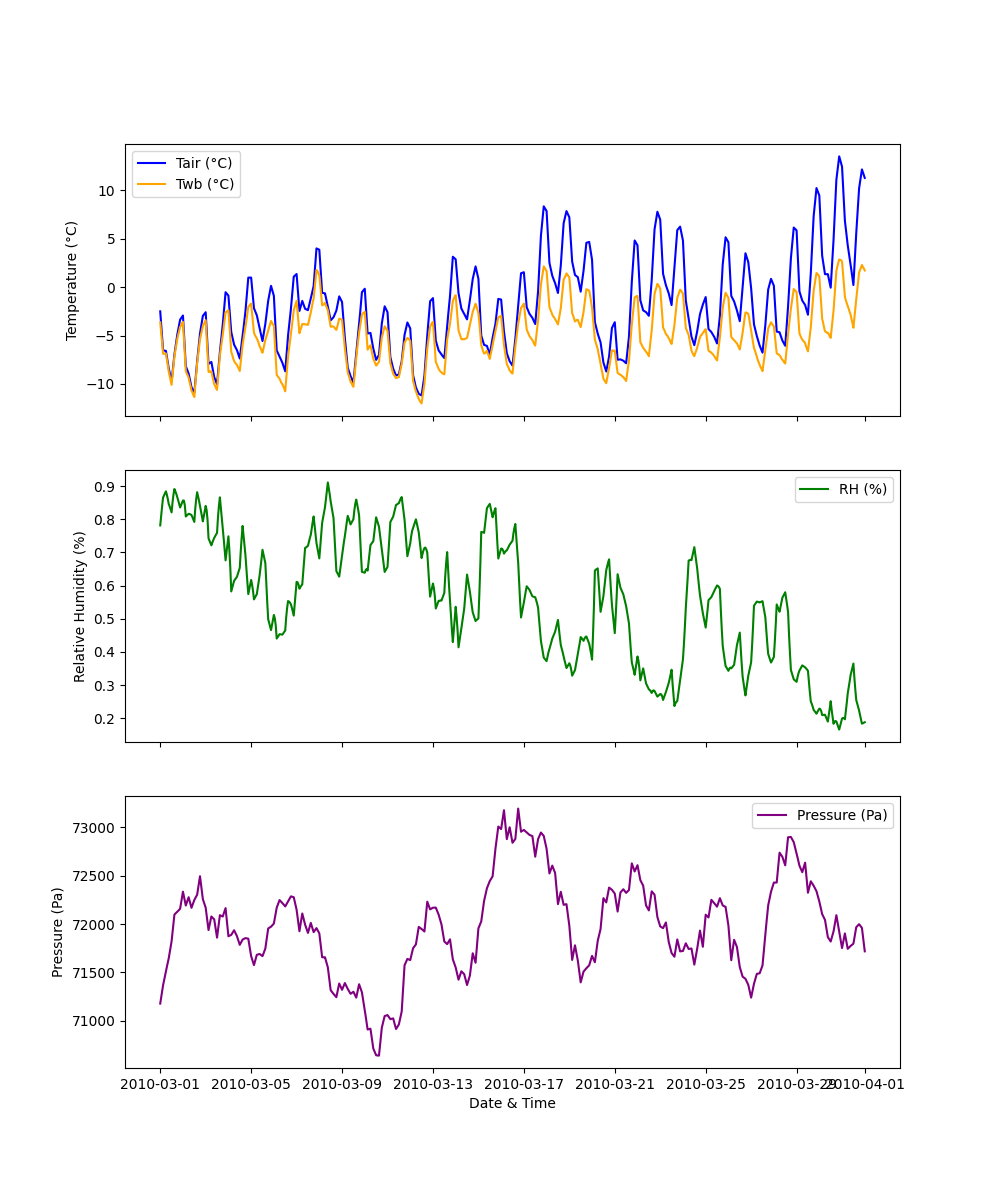

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
ax[0].plot(quemazon_data.index, quemazon_data['Tair_c'], label='Tair (°C)', color='blue')
ax[0].plot(quemazon_data.index, quemazon_data['Twb_c'], label='Twb (°C)', color='orange')
ax[0].set_ylabel('Temperature (°C)')
ax[0].legend()

ax[1].plot(quemazon_data.index, quemazon_data['RH'], label='RH (%)', color='green')
ax[1].set_ylabel('Relative Humidity (%)')
ax[1].legend()

ax[2].plot(quemazon_data.index, quemazon_data['PSurf'], label='Pressure (Pa)', color='purple')
ax[2].set_ylabel('Pressure (Pa)')
ax[2].legend()
ax[2].set_xlabel('Date & Time')

In [15]:
quemazon_data['2010-03-07 18:00':'2010-03-08 06:00'].head()

,Tair,Qair,PSurf,Tair_c,RH,Twb_c
Date&Time,,,,,,
2010-03-07 18:00:00+00:00,273.27,0.004319,71916.3,0.12,0.808194,-1.169062
2010-03-07 19:00:00+00:00,274.57,0.004590,71930.6,1.42,0.782071,-0.181562
2010-03-07 20:00:00+00:00,275.86,0.004861,71944.2,2.71,0.755576,0.795938
2010-03-07 21:00:00+00:00,277.16,0.005134,71957.9,4.01,0.728030,1.783438
2010-03-07 22:00:00+00:00,277.11,0.005011,71939.9,3.96,0.712904,1.655313


In [16]:
q_test = 0.005134  # kg/kg
p_test = 71957.9  # Pa
T_test = 277.16 - 273.15  # degC
test = calculate_wetbulb(T_test, q_test, p_test)  # Example calculation
print(f"Test wet-bulb temperature: {test:.2f} °C at T={T_test:.2f} °C, q={q_test:.6f} kg/kg, p={p_test:.1f} Pa")

Test wet-bulb temperature: 1.78 °C at T=4.01 °C, q=0.005134 kg/kg, p=71957.9 Pa


### Implement Wang 2019 partitioning scheme

In [17]:
# Equation coefficients
a = 6.99e-5
b = 2.0
c = 3.97

### Initial plot of function to ensure it matches Wang 2019 Figure 1
There is a typo in Wang 2019 equation 1. (Tw+c) should be part of the exponential.

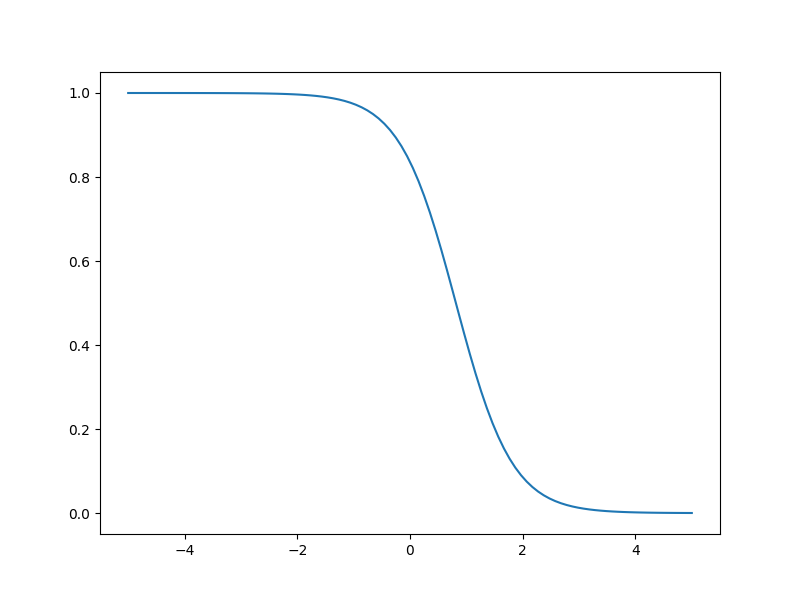

In [ ]:
x = np.linspace(-5, 5, 100)
x_K = x + 273.15
fs = 1/(1 + a * np.exp(b*(x + c)))
plt.figure(figsize=(8,6))
plt.plot(x, fs, label='Snow Fraction')


<Axes: xlabel='Date&Time'>

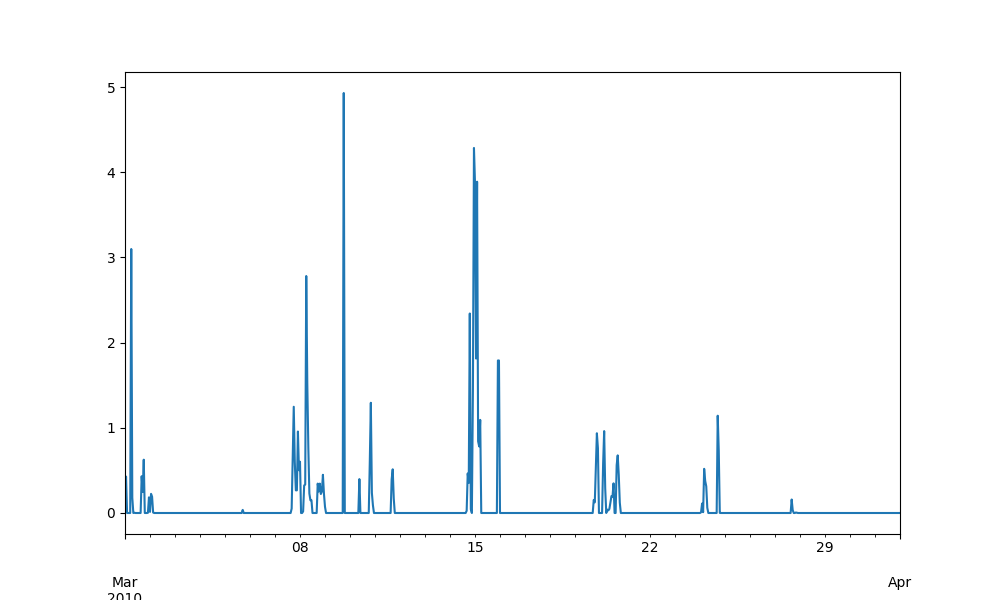

In [32]:
plt.figure(figsize=(10, 6))
quemazon.data['Rainf'].plot()